Explained variance ratio (PC1, PC2, PC3): [9.885e-01 4.800e-03 4.000e-04]
Cumulative explained variance: 0.9936
Overall reconstruction RMSE (vol points): 0.0028

Day 2025-12-01, 90d maturity slice:
 moneyness  actual_iv  reconstructed_iv  residual
      0.85    0.17318           0.17330  -0.00012
      0.90    0.16098           0.16373  -0.00275
      0.95    0.15604           0.15531   0.00073
      1.00    0.14893           0.14712   0.00181
      1.05    0.13948           0.13861   0.00088
      1.10    0.13661           0.13336   0.00325
      1.15    0.11975           0.12559  -0.00584


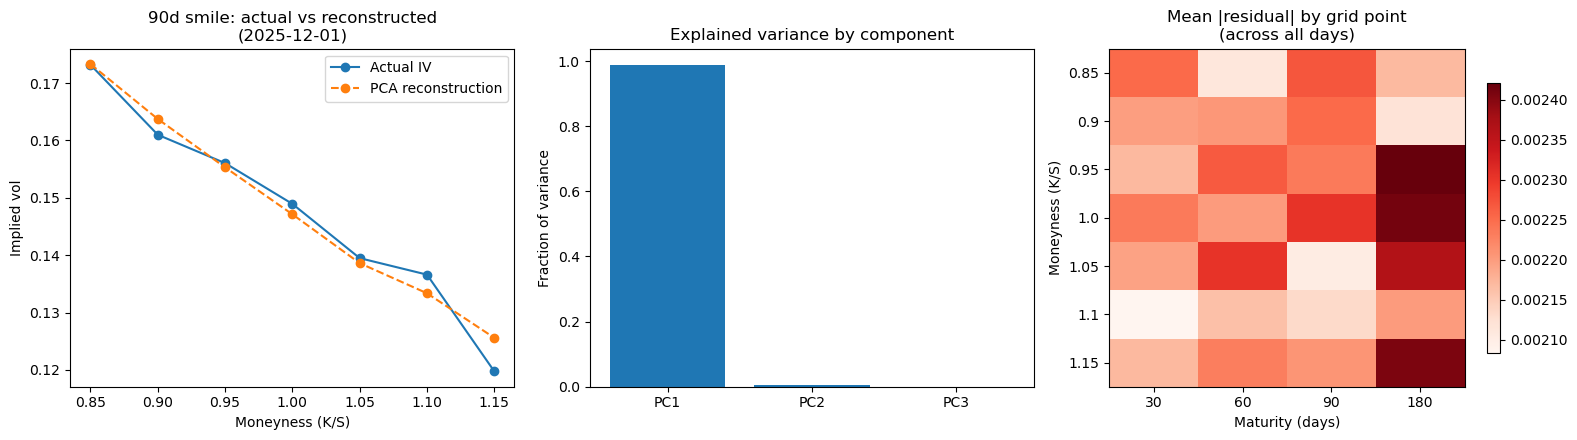

In [2]:
"""
PCA Reconstruction of a Dummy Implied Vol Surface
==================================================

1. Build a synthetic (moneyness x maturity) IV surface panel over many days,
   driven by 3 latent factors (level, skew, curvature) + noise.
2. Run PCA on the panel.
3. Reconstruct the surface from the top-3 components.
4. Compare actual vs reconstructed IV for one day/maturity slice.
5. Plot: (a) actual vs reconstructed smile, (b) explained variance,
   (c) residual heatmap across the whole panel.

Replace `generate_dummy_iv_panel()` with a real data loader to use this
on live implied vol surfaces.
"""

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

RNG = np.random.default_rng(7)

MONEYNESS = np.array([0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15])
MATURITIES = np.array([30, 60, 90, 180])


# ---------------------------------------------------------------
# 1. Dummy vol surface
# ---------------------------------------------------------------

def mean_reverting_factor(n, kappa, vol, rng):
    f = np.zeros(n)
    for i in range(1, n):
        f[i] = f[i - 1] * (1 - kappa) + rng.normal(0, vol)
    return f


def generate_dummy_iv_panel(n_days=500):
    grid = [(m, t) for t in MATURITIES for m in MONEYNESS]
    n_points = len(grid)

    base = np.array([
        0.22 - 0.15 * (m - 1) + 0.10 * (m - 1) ** 2 + 0.02 * np.sqrt(t / 90)
        for (m, t) in grid
    ])

    level = mean_reverting_factor(n_days, kappa=0.03, vol=0.010, rng=RNG)
    skew_f = mean_reverting_factor(n_days, kappa=0.04, vol=0.006, rng=RNG)
    curv_f = mean_reverting_factor(n_days, kappa=0.05, vol=0.004, rng=RNG)

    loadings_level = np.ones(n_points)
    loadings_skew = np.array([-(m - 1) for (m, t) in grid])
    loadings_curv = np.array([
        (m - 1) ** 2 - np.mean([(mm - 1) ** 2 for mm in MONEYNESS])
        for (m, t) in grid
    ])

    X = np.zeros((n_days, n_points))
    for d in range(n_days):
        surface = (base
                   + loadings_level * level[d]
                   + loadings_skew * skew_f[d]
                   + loadings_curv * curv_f[d]
                   + RNG.normal(0, 0.003, n_points))
        X[d] = np.clip(surface, 0.03, None)  # IV floor

    cols = pd.MultiIndex.from_tuples(grid, names=["moneyness", "maturity"])
    dates = pd.bdate_range("2024-01-02", periods=n_days)
    return pd.DataFrame(X, index=dates, columns=cols)


# ---------------------------------------------------------------
# 2. PCA fit + 3. reconstruction
# ---------------------------------------------------------------

def fit_and_reconstruct(iv_panel, n_components=3):
    mean_ = iv_panel.values.mean(axis=0)
    Xc = iv_panel.values - mean_

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(Xc)
    loadings = pca.components_
    explained = pca.explained_variance_ratio_

    recon = scores @ loadings + mean_
    recon_panel = pd.DataFrame(recon, index=iv_panel.index, columns=iv_panel.columns)
    resid_panel = iv_panel - recon_panel

    return pca, scores, loadings, explained, recon_panel, resid_panel


# ---------------------------------------------------------------
# 4. Run + compare + 5. plot
# ---------------------------------------------------------------

if __name__ == "__main__":
    iv_panel = generate_dummy_iv_panel(n_days=500)
    pca, scores, loadings, explained, recon_panel, resid_panel = fit_and_reconstruct(iv_panel)

    print("Explained variance ratio (PC1, PC2, PC3):", np.round(explained, 4))
    print("Cumulative explained variance:", round(explained.sum(), 4))

    rmse = np.sqrt((resid_panel.values ** 2).mean())
    print("Overall reconstruction RMSE (vol points):", round(rmse, 5))

    # slice for the smile comparison plot
    day = iv_panel.index[-1]
    maturity_slice = 90
    actual_slice = iv_panel.xs(maturity_slice, level="maturity", axis=1).loc[day].sort_index()
    recon_slice = recon_panel.xs(maturity_slice, level="maturity", axis=1).loc[day].sort_index()

    compare = pd.DataFrame({
        "moneyness": actual_slice.index,
        "actual_iv": actual_slice.values,
        "reconstructed_iv": recon_slice.values,
    })
    compare["residual"] = compare["actual_iv"] - compare["reconstructed_iv"]
    print(f"\nDay {day.date()}, {maturity_slice}d maturity slice:")
    print(compare.round(5).to_string(index=False))

    # ---- plots ----
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # (a) actual vs reconstructed smile
    axes[0].plot(compare["moneyness"], compare["actual_iv"], "o-", label="Actual IV")
    axes[0].plot(compare["moneyness"], compare["reconstructed_iv"], "o--", label="PCA reconstruction")
    axes[0].set_title(f"{maturity_slice}d smile: actual vs reconstructed\n({day.date()})")
    axes[0].set_xlabel("Moneyness (K/S)")
    axes[0].set_ylabel("Implied vol")
    axes[0].legend()

    # (b) explained variance
    axes[1].bar([f"PC{i+1}" for i in range(len(explained))], explained)
    axes[1].set_title("Explained variance by component")
    axes[1].set_ylabel("Fraction of variance")

    # (c) residual heatmap across the whole panel (average |residual| per grid point)
    mean_abs_resid = resid_panel.abs().mean(axis=0).unstack("maturity")
    im = axes[2].imshow(mean_abs_resid.values, aspect="auto", cmap="Reds")
    axes[2].set_xticks(range(len(mean_abs_resid.columns)))
    axes[2].set_xticklabels(mean_abs_resid.columns)
    axes[2].set_yticks(range(len(mean_abs_resid.index)))
    axes[2].set_yticklabels(mean_abs_resid.index)
    axes[2].set_xlabel("Maturity (days)")
    axes[2].set_ylabel("Moneyness (K/S)")
    axes[2].set_title("Mean |residual| by grid point\n(across all days)")
    fig.colorbar(im, ax=axes[2], shrink=0.8)

    plt.tight_layout()

In [4]:
scores

array([[ 1.97081155e-01, -3.10227329e-03, -3.69644321e-03],
       [ 1.92506083e-01, -6.37123603e-03, -3.40682973e-03],
       [ 2.07345188e-01, -2.71699489e-04,  3.69990774e-03],
       ...,
       [-3.32194555e-01, -3.93035198e-03,  1.38832078e-03],
       [-3.70943510e-01, -4.60324308e-03, -3.82548154e-03],
       [-3.00413383e-01, -3.39650752e-03, -1.74238672e-03]])